<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/DAY_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
y_test.shape

(10000,)

In [ ]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [ ]:
x_train.max()

255

In [ ]:
x_train.min()

0

In [ ]:
x_train = x_train/255.0
x_train.min()

0.0

In [ ]:
print(x_train.min())
print(x_train.max())


0.0
1.0


In [ ]:
x_test = x_test/255.0

In [ ]:
print(x_test.min())
print(x_test.max())


0.0
1.0


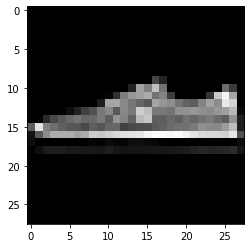

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[14],cmap='gray')   #(1,28,28,1)

In [ ]:
y_train[14]  #7 corresponds to sneakers

7

In [ ]:
x_train = x_train.reshape((60000,28,28,1)) #CNN expects 4 dimension as mentioned in the keras library
x_test = x_test.reshape((10000,28,28,1))

In [ ]:
#[0,1,2,3,4,5,6,7,8,9]-sparse categorical
#[0,0,0,0,0,0,0,0,1,0] - [8]   categorical data[one hot encoding format]

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
y_train = to_categorical(y_train,10) #10 is mentioned because there are 10 categories

In [ ]:
y_test = to_categorical(y_test,10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [ ]:
model = Sequential()

In [ ]:
model.add(Conv2D(filters=64,kernel_size=(5,5), input_shape=(28,28,1), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(filters=64,kernel_size=(5,5), input_shape=(28,28,1), activation='relu'))
model.add(MaxPooling2D())  #2x2 window

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [ ]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 41s 6ms/step - loss: 0.4350 - accuracy: 0.8409
Epoch 2/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2875 - accuracy: 0.8938
Epoch 3/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2461 - accuracy: 0.9088
Epoch 4/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.2169 - accuracy: 0.9183
Epoch 5/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1867 - accuracy: 0.9300
Epoch 6/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1680 - accuracy: 0.9357
Epoch 7/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1465 - accuracy: 0.9433
Epoch 8/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1290 - accuracy: 0.9507
Epoch 9/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1161 - accuracy: 0.9560
Epoch 10/10
1875/1875 [==============================] - 11s 6ms/step - l

In [ ]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.3013 - accuracy: 0.9125


[0.3013014793395996, 0.9125000238418579]

In [ ]:
import numpy as np
a = model.predict(x_test[250].reshape(1,28,28,1))
a = np.argmax(a,axis=1)
print(a)
label = 'T-shirt/top Trouser Pullover Dress Coat Sandal Shirt Sneaker Bag Ankle-boot'
label = label.split()
op = label[a[0]]
print(op)

[9]
Ankle-boot
